# Regression Model Benchmark

Compare variational quantum regression against classical regression baselines using shared datasets, seeds, metrics, and runtime reporting.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.benchmarks import compare_regression_models
from qml.reporting import print_table
import matplotlib.pyplot as plt

In [3]:
CONFIG = {
    "dataset": "sine",
    "seeds": [0],
    "n_samples": 32,
    "noise": 0.08,
    "test_size": 0.25,
    "tune_classical": False,
    "cv": 3,
}

models = [
    "vqr",
    "quantum_kernel_regressor",
    "quantum_gaussian_process_regressor",
    "quantum_reservoir_regressor",
    "ridge_regression",
    "kernel_ridge_regression",
    "svr_regression",
]

model_kwargs = {
    "vqr": {"n_layers": 1, "steps": 5, "step_size": 0.1},
    "quantum_reservoir_regressor": {"n_layers": 1},
}

In [4]:
def summary_rows(result, metric):
    rows = []
    higher_is_better = result["best_model"]["higher_is_better"]
    for model, stats in result["summary"].items():
        metric_stats = stats[metric]
        gap_stats = stats["generalization_gap"]
        runtime_stats = stats["runtime_seconds"]
        parameter_stats = stats.get("trainable_parameters")
        depth_stats = stats.get("estimated_depth")
        rows.append(
            {
                "model": model,
                metric: metric_stats["mean"],
                "ci95_low": metric_stats["ci95_low"],
                "ci95_high": metric_stats["ci95_high"],
                "gap": gap_stats["mean"],
                "runtime_s": runtime_stats["mean"],
                "params": "" if parameter_stats is None else parameter_stats["mean"],
                "depth": "" if depth_stats is None else depth_stats["mean"],
                "runs": stats["n_runs"],
            }
        )
    return sorted(rows, key=lambda row: row[metric], reverse=higher_is_better)


def paired_rows(result):
    comparison = result["paired_vs_best_classical"]
    return [
        {
            "model": model,
            "mean_delta": stats["mean_delta"]["mean"],
            "wins": stats["wins"],
            "losses": stats["losses"],
            "ties": stats["ties"],
            "pairs": stats["n_pairs"],
        }
        for model, stats in comparison["comparisons"].items()
    ]

## Full Regressor Comparison

In [5]:
regression_benchmark = compare_regression_models(
    models=models,
    seeds=CONFIG["seeds"],
    n_samples=CONFIG["n_samples"],
    noise=CONFIG["noise"],
    test_size=CONFIG["test_size"],
    dataset=CONFIG["dataset"],
    tune_classical=CONFIG["tune_classical"],
    cv=CONFIG["cv"],
    model_kwargs=model_kwargs,
    save=False,
)

print_table(summary_rows(regression_benchmark, "test_mse"), title="Regression summary by MSE")
print_table(summary_rows(regression_benchmark, "test_mae"), title="Regression summary by MAE")
print_table(paired_rows(regression_benchmark), title=f"Paired MSE deltas vs {regression_benchmark['paired_vs_best_classical']['reference_model']}")
print_table(regression_benchmark["best_model"], title="Best model")

Regression summary by MSE
+------------------------------------+-----------+-----------+-----------+------------+------------+--------+-------+------+
| model                              | test_mse  | ci95_low  | ci95_high | gap        | runtime_s  | params | depth | runs |
+------------------------------------+-----------+-----------+-----------+------------+------------+--------+-------+------+
| svr_regression                     | 0.0801907 | 0.0801907 | 0.0801907 | -0.0136897 | 0.00275484 |        |       | 1    |
| vqr                                | 0.122342  | 0.122342  | 0.122342  | -0.773642  | 0.881965   | 4      | 5     | 1    |
| kernel_ridge_regression            | 0.197459  | 0.197459  | 0.197459  | 0.0338305  | 0.00322244 |        |       | 1    |
| quantum_gaussian_process_regressor | 0.373078  | 0.373078  | 0.373078  | 0.11375    | 1.07821    | 0      | 3     | 1    |
| quantum_kernel_regressor           | 0.419824  | 0.419824  | 0.419824  | 0.0973739  | 1.1084     

## Summary Plots

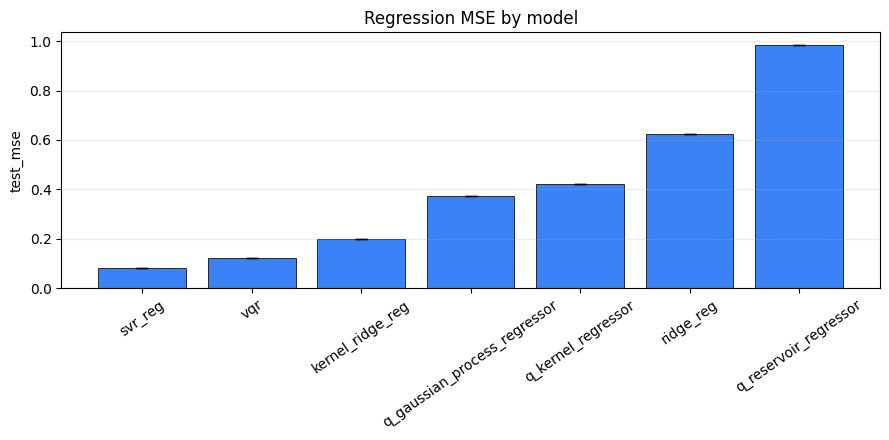

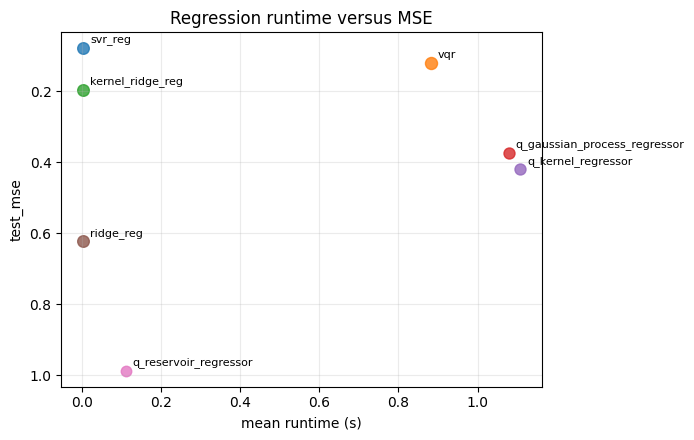

In [6]:

import matplotlib.pyplot as plt


def _short_label(label):
    return label.replace("quantum_", "q_").replace("_regression", "_reg").replace("_classifier", "_clf")


def plot_metric_bars(rows, metric, title, *, lower_is_better=False):
    ordered = sorted(rows, key=lambda row: row[metric], reverse=not lower_is_better)
    labels = [_short_label(row["model"]) for row in ordered]
    values = [row[metric] for row in ordered]
    errors = [
        [max(0.0, row[metric] - row.get("ci95_low", row[metric])) for row in ordered],
        [max(0.0, row.get("ci95_high", row[metric]) - row[metric]) for row in ordered],
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(labels, values, yerr=errors, capsize=4, color="#3b82f6", edgecolor="#1f2937", linewidth=0.7)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_runtime_scatter(rows, metric, title, *, lower_is_better=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for row in rows:
        marker_size = 70 if row.get("depth") == "" else 45 + 6 * float(row["depth"])
        ax.scatter(row["runtime_s"], row[metric], s=marker_size, alpha=0.8)
        ax.annotate(_short_label(row["model"]), (row["runtime_s"], row[metric]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("mean runtime (s)")
    ax.set_ylabel(metric)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


def plot_dataset_bars(rows, metric, title, *, lower_is_better=False):
    datasets = list(dict.fromkeys(row["dataset"] for row in rows))
    models = list(dict.fromkeys(row["model"] for row in rows))
    width = 0.8 / max(1, len(models))
    x = list(range(len(datasets)))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for index, model in enumerate(models):
        values = []
        for dataset in datasets:
            match = next((row for row in rows if row["dataset"] == dataset and row["model"] == model), None)
            values.append(float("nan") if match is None else match[metric])
        offsets = [position - 0.4 + width / 2 + index * width for position in x]
        ax.bar(offsets, values, width=width, label=_short_label(model))
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xticks(x, datasets)
    if lower_is_better:
        ax.invert_yaxis()
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

summary = summary_rows(regression_benchmark, "test_mse")
plot_metric_bars(summary, "test_mse", "Regression MSE by model", lower_is_better=True)
plot_runtime_scatter(summary, "test_mse", "Regression runtime versus MSE", lower_is_better=True)

## Dataset Sweep

In [7]:
sweep_models = ["vqr", "quantum_kernel_regressor", "quantum_reservoir_regressor", "ridge_regression"]
sweep_datasets = ["linear", "sine", "diabetes"]

sweep_rows = []
for dataset in sweep_datasets:
    result = compare_regression_models(
        models=sweep_models,
        seeds=CONFIG["seeds"],
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        dataset=dataset,
        model_kwargs={"vqr": model_kwargs["vqr"], "quantum_reservoir_regressor": {"n_layers": 1}},
        save=False,
    )
    for row in summary_rows(result, "test_mse"):
        sweep_rows.append({"dataset": dataset, **row})

print_table(sweep_rows, title="Regression dataset sweep")

Regression dataset sweep
+----------+-----------------------------+------------+------------+------------+------------+------------+--------+-------+------+
| dataset  | model                       | test_mse   | ci95_low   | ci95_high  | gap        | runtime_s  | params | depth | runs |
+----------+-----------------------------+------------+------------+------------+------------+------------+--------+-------+------+
| linear   | ridge_regression            | 0.00322048 | 0.00322048 | 0.00322048 | 0.00141887 | 0.00445475 |        |       | 1    |
| linear   | quantum_kernel_regressor    | 0.168163   | 0.168163   | 0.168163   | -0.0173032 | 0.778108   | 0      | 3     | 1    |
| linear   | vqr                         | 1.12147    | 1.12147    | 1.12147    | 0.0589046  | 1.21235    | 4      | 5     | 1    |
| linear   | quantum_reservoir_regressor | 1.29671    | 1.29671    | 1.29671    | 0.325749   | 0.107004   | 0      | 2     | 1    |
| sine     | vqr                         | 0.122342

## Dataset Sweep Plot

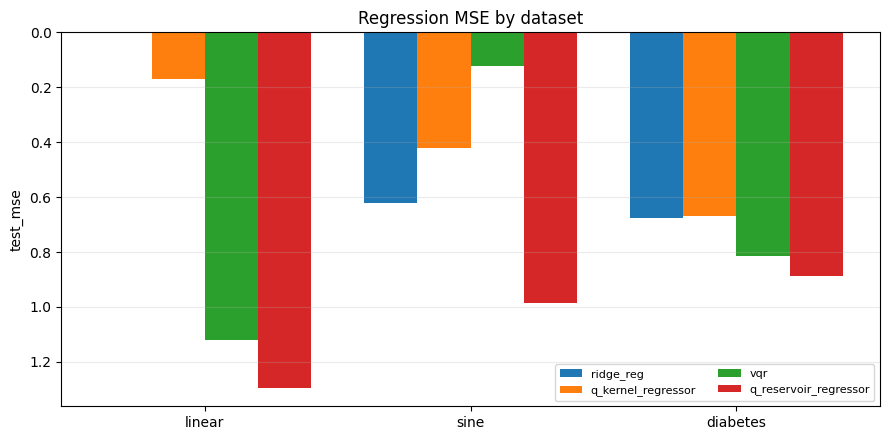

In [8]:
plot_dataset_bars(sweep_rows, "test_mse", "Regression MSE by dataset", lower_is_better=True)